# Technology Participation & Acceptance Rates: IV Algorithm vs Real ELEXON (2024)

This notebook investigates **which technologies (carriers) provide balancing services** in both the IV zonal clearing algorithm and the real ELEXON Balancing Mechanism, and how participation varies by zone and direction.

Key questions:
- Which carriers (gas, wind, battery, hydro, etc.) dominate the accepted balancing volume?
- Does the IV model select the same carrier mix as the real SO?
- How does technology mix vary geographically (north-to-south zones) and by direction (turn-up / turndown)?
- What fraction of submitted volume is actually accepted, by carrier and zone?
- Which individual BMUs are "indispensable" — carrying disproportionate balancing load?
- How does the technology mix evolve across the year (seasonal patterns)?
- What are the price distributions by carrier that drive merit-order selection?

**Data sources:**
- **IV accepted actions**: `results/{date}/IV_clearing_accepted_actions_flex.csv` — per-action detail with `carrier_type`, `zone`, `action_type`, `volume_mwh`, `cost_gbp`, `price_per_mwh`
- **IV dispatch changes**: `results/{date}/IV_dispatch_changes_by_zone_and_type_flex.csv` — zone × carrier aggregation
- **Real accepted actions**: `data/base/{date}/bids.csv` + `offers.csv` — BMU-level accepted volumes and prices
- **Submitted actions**: `data/base/{date}/submitted_bids.csv` + `submitted_offers.csv` — what was available to the market
- **BMU classification**: `data/prerun/bmu_constraint_classification.csv` — maps BMU → carrier type + zone (via constraint boundaries)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

ROOT = Path(r"c:\GBPower")
RESULTS_DIR = ROOT / "results"
DATA_DIR = ROOT / "data" / "base"
PRERUN_DIR = ROOT / "data" / "prerun"

# Discover available dates
all_dates = sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith("2024")])
print(f"Found {len(all_dates)} result date folders (2024)")
print(f"Date range: {all_dates[0]} to {all_dates[-1]}")

Found 366 result date folders (2024)
Date range: 2024-01-01 to 2024-12-31


## BMU Classification & Carrier Mapping

We need a consistent mapping from BMU IDs to **carrier type** and **zone** that works for both the IV model and real ELEXON data. The precomputed `bmu_constraint_classification.csv` provides this with the same consolidated carrier categories used by the IV model.

In [6]:
# Load BMU classification (maps BMU → carrier + constraint zone)
bmu_class = pd.read_csv(PRERUN_DIR / 'bmu_constraint_classification.csv')
bmu_class = bmu_class.set_index('NationalGridBmUnit')

def classify_to_zone(row):
    """Assign a colour zone based on constraint side columns (north-to-south)."""
    if row.get('SSE-SP_side') == 'north':
        return 'red'
    elif row.get('SCOTEX_side') == 'north':
        return 'orange'
    elif row.get('SSHARN_side') == 'north':
        return 'green'
    elif row.get('FLOWSTH_side') == 'north':
        return 'blue'
    elif row.get('SEIMP_side') == 'north':
        return 'purple'
    else:
        return 'yellow'

bmu_class['zone'] = bmu_class.apply(classify_to_zone, axis=1)

# Zone metadata for consistent ordering / labelling
ZONE_ORDER = ['red', 'orange', 'green', 'blue', 'purple', 'yellow']
ZONE_NAMES = {
    'red': 'North Scotland',
    'orange': 'SSE-SP → SCOTEX',
    'green': 'SCOTEX → SSHARN',
    'blue': 'SSHARN → FLOWSTH',
    'purple': 'FLOWSTH → SEIMP',
    'yellow': 'South England',
}

# Carrier colour palette (consistent throughout notebook)
CARRIER_COLORS = {
    'fossil': '#8B4513',
    'battery': '#9467BD',
    'onwind': '#2CA02C',
    'offwind': '#17BECF',
    'biomass': '#D62728',
    'hydro': '#1F77B4',
    'PHS': '#4477AA',
    'nuclear': '#FF7F0E',
    'solar': '#FFD700',
    'cascade': '#7F7F7F',
    'interconnector': '#E377C2',
    'demand_flex': '#BCBD22',
    'load': '#AAAAAA',
    'other': '#CCCCCC',
}

print(f"BMU classification: {len(bmu_class)} units")
print(f"\nCarrier distribution:")
print(bmu_class['carrier'].value_counts().to_string())
print(f"\nZone distribution:")
print(bmu_class['zone'].value_counts().reindex(ZONE_ORDER).to_string())

BMU classification: 1056 units

Carrier distribution:
carrier
interconnector    628
onwind            105
fossil            100
offwind            79
battery            66
nuclear            23
hydro              18
PHS                17
biomass             9
cascade             7
load                2
solar               2

Zone distribution:
zone
red        66
orange    102
green      21
blue      187
purple    487
yellow    193


## Load All IV Accepted Actions (full year)

Concatenate `IV_clearing_accepted_actions_flex.csv` across all 366 days into one DataFrame. This gives us per-action granularity with carrier type, zone, direction, volume, price, and cost.

In [7]:
iv_actions_list = []
missing_iv = 0
empty_iv = 0

for day_str in tqdm(all_dates, desc="Loading IV accepted actions"):
    fpath = RESULTS_DIR / day_str / 'IV_clearing_accepted_actions_flex.csv'
    if not fpath.exists():
        missing_iv += 1
        continue
    try:
        df = pd.read_csv(fpath)
        if df.empty:
            empty_iv += 1
            continue
    except Exception:
        empty_iv += 1
        continue
    df['date'] = day_str
    iv_actions_list.append(df)

iv_actions = pd.concat(iv_actions_list, ignore_index=True)
iv_actions['timestamp'] = pd.to_datetime(iv_actions['timestamp'])
iv_actions['date'] = pd.to_datetime(iv_actions['date'])
iv_actions['month'] = iv_actions['date'].dt.to_period('M')

# Volume in MWh (volume_mwh is MW per SP, multiply by 0.5 for MWh)
iv_actions['volume_mwh_actual'] = iv_actions['volume_mwh'] * 0.5

print(f"Loaded {len(iv_actions):,} IV accepted actions across {len(all_dates) - missing_iv - empty_iv} days")
print(f"Missing days: {missing_iv}, Empty/corrupt files: {empty_iv}")
print(f"\nCarrier types in IV actions: {sorted(iv_actions['carrier_type'].unique())}")
print(f"Zones in IV actions: {sorted(iv_actions['zone'].unique())}")
print(f"Action types: {iv_actions['action_type'].unique()}")
print(f"\nTotal IV volume: {iv_actions['volume_mwh_actual'].sum()/1e6:.2f} TWh")
print(f"Total IV cost: £{iv_actions['cost_gbp'].sum()/1e6:.1f}M")

Loading IV accepted actions: 100%|██████████| 366/366 [00:00<00:00, 448.12it/s]

Loaded 144,630 IV accepted actions across 355 days
Missing days: 3, Empty/corrupt files: 8

Carrier types in IV actions: ['PHS', 'battery', 'biomass', 'cascade', 'fossil', 'hydro', 'offwind', 'onwind', 'solar']
Zones in IV actions: ['blue', 'green', 'orange', 'purple', 'red', 'yellow']
Action types: ['offer' 'bid']

Total IV volume: 9.63 TWh
Total IV cost: £486.4M


## Load All Real ELEXON Accepted Actions (full year)

Parse `bids.csv` and `offers.csv` for each day, pivot from wide format (BMU columns) to long format, and merge with BMU classification to get carrier type and zone.

In [8]:
real_actions_list = []
missing_real = 0

for day_str in tqdm(all_dates, desc="Loading real ELEXON accepted actions"):
    for file_type in ['offers', 'bids']:
        fpath = DATA_DIR / day_str / f'{file_type}.csv'
        if not fpath.exists():
            if file_type == 'offers':
                missing_real += 1
            continue
        
        df = pd.read_csv(fpath, index_col=[0, 1])
        vols = df.loc[pd.IndexSlice[:, 'vol'], :]
        prices = df.loc[pd.IndexSlice[:, 'price'], :]
        vols.index = vols.index.droplevel(1)
        prices.index = prices.index.droplevel(1)
        
        # Melt to long format: one row per (timestamp, BMU)
        for bmu in vols.columns:
            v_series = vols[bmu].dropna()
            p_series = prices[bmu].reindex(v_series.index)
            
            # Skip if all zeros
            if (v_series == 0).all():
                continue
            
            # Look up carrier and zone
            if bmu in bmu_class.index:
                carrier = bmu_class.loc[bmu, 'carrier']
                zone = bmu_class.loc[bmu, 'zone']
            else:
                carrier = 'other'
                zone = 'unknown'
            
            vol_mwh = v_series.sum() * 0.5
            cost_gbp = (v_series * p_series * 0.5).sum()
            
            real_actions_list.append({
                'date': day_str,
                'bmu': bmu,
                'action_type': 'offer' if file_type == 'offers' else 'bid',
                'carrier_type': carrier,
                'zone': zone,
                'volume_mwh': vol_mwh,
                'cost_gbp': cost_gbp,
            })

real_actions = pd.DataFrame(real_actions_list)
real_actions['date'] = pd.to_datetime(real_actions['date'])
real_actions['month'] = real_actions['date'].dt.to_period('M')

print(f"Loaded {len(real_actions):,} real BMU-day-action rows across {len(all_dates) - missing_real} days")
print(f"Missing days: {missing_real}")
print(f"\nCarrier types in real actions: {sorted(real_actions['carrier_type'].unique())}")
print(f"Unique BMUs: {real_actions['bmu'].nunique()}")
print(f"\nTotal real volume: {real_actions['volume_mwh'].sum()/1e6:.2f} TWh")
print(f"Total real cost: £{real_actions['cost_gbp'].sum()/1e6:.1f}M")

Loading real ELEXON accepted actions: 100%|██████████| 366/366 [01:05<00:00,  5.62it/s]


Loaded 95,335 real BMU-day-action rows across 364 days
Missing days: 2

Carrier types in real actions: ['PHS', 'battery', 'biomass', 'cascade', 'fossil', 'hydro', 'offwind', 'onwind', 'other']
Unique BMUs: 512

Total real volume: 13.62 TWh
Total real cost: £842.0M


---
## Plot 3a: Annual Volume by Carrier Type — IV vs Real

A side-by-side comparison of how much balancing volume (MWh) each carrier type contributes, split by direction (offers = turn-up, bids = turndown). This directly reveals whether the IV model's technology preferences align with reality.

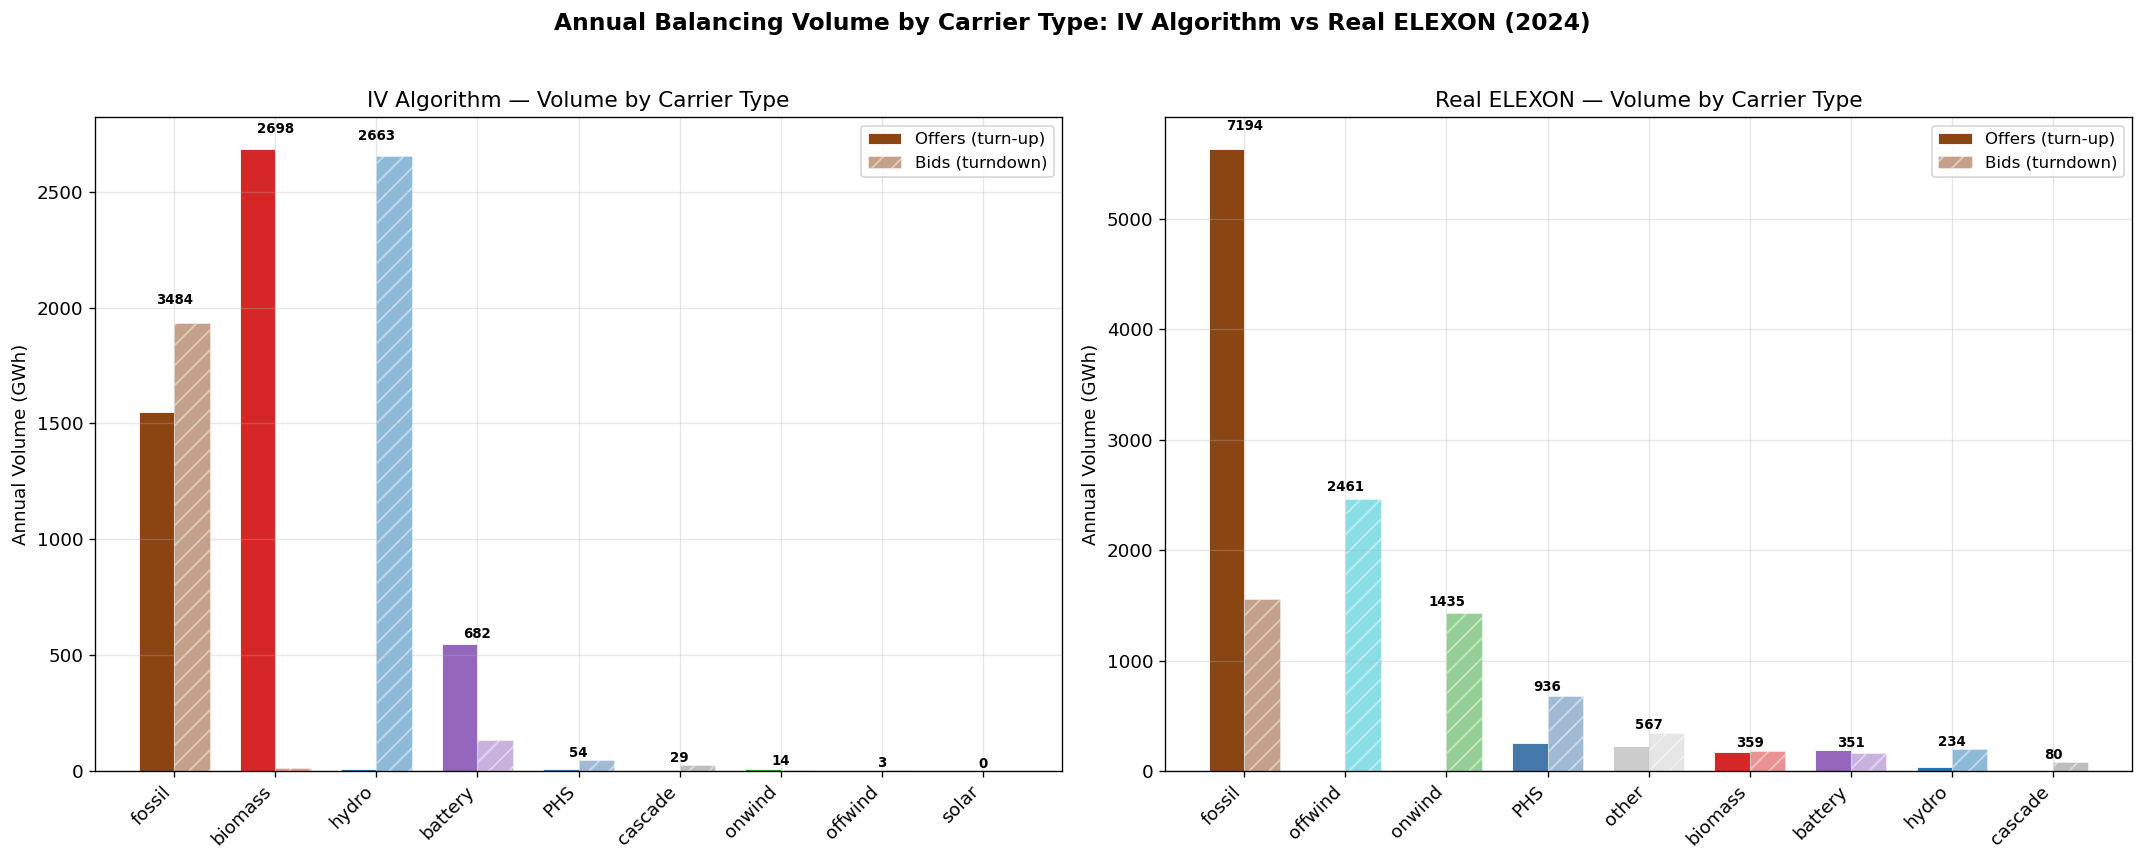


=== Volume by carrier (GWh) ===
              IV Offers  IV Bids  IV Total  Real Offers  Real Bids  Real Total
carrier_type                                                                  
PHS                 7.7     46.4      54.1        256.2      679.8       936.0
battery           547.1    135.3     682.4        186.1      165.3       351.4
biomass          2686.8     11.7    2698.5        175.1      183.4       358.6
cascade             4.3     24.6      28.9          0.9       79.3        80.3
fossil           1551.3   1932.5    3483.8       5639.8     1554.7      7194.5
hydro               6.5   2656.2    2662.7         39.1      194.5       233.5
offwind             0.0      2.9       2.9          0.7     2460.3      2461.0
onwind             10.1      4.2      14.3          0.1     1434.8      1434.9
other               0.0      0.0       0.0        223.0      343.9       567.0
solar               0.0      0.0       0.0          0.0        0.0         0.0


In [9]:
# --- Aggregate by carrier and action type ---
iv_by_carrier = iv_actions.groupby(['carrier_type', 'action_type'])['volume_mwh_actual'].sum().unstack(fill_value=0)
iv_by_carrier['total'] = iv_by_carrier.sum(axis=1)
iv_by_carrier = iv_by_carrier.sort_values('total', ascending=False)

real_by_carrier = real_actions.groupby(['carrier_type', 'action_type'])['volume_mwh'].sum().unstack(fill_value=0)
real_by_carrier['total'] = real_by_carrier.sum(axis=1)
real_by_carrier = real_by_carrier.sort_values('total', ascending=False)

# Align carrier order — union of both, sorted by max total
all_carriers = list(dict.fromkeys(
    list(iv_by_carrier.index) + list(real_by_carrier.index)
))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, data, title, vol_col in [
    (axes[0], iv_by_carrier, 'IV Algorithm', 'volume_mwh_actual'),
    (axes[1], real_by_carrier, 'Real ELEXON', 'volume_mwh'),
]:
    carriers = data.index.tolist()
    x = np.arange(len(carriers))
    width = 0.35
    
    offer_vals = data.get('offer', pd.Series(0, index=carriers)).reindex(carriers, fill_value=0) / 1e3
    bid_vals = data.get('bid', pd.Series(0, index=carriers)).reindex(carriers, fill_value=0) / 1e3
    
    colors_offer = [CARRIER_COLORS.get(c, '#CCCCCC') for c in carriers]
    colors_bid = [CARRIER_COLORS.get(c, '#CCCCCC') for c in carriers]
    
    bars1 = ax.bar(x - width/2, offer_vals, width, label='Offers (turn-up)',
                   color=colors_offer, edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x + width/2, bid_vals, width, label='Bids (turndown)',
                   color=colors_bid, alpha=0.5, edgecolor='white', linewidth=0.5,
                   hatch='//')
    
    ax.set_xticks(x)
    ax.set_xticklabels(carriers, rotation=45, ha='right')
    ax.set_ylabel('Annual Volume (GWh)')
    ax.set_title(f'{title} — Volume by Carrier Type')
    ax.legend(loc='upper right')
    
    # Add total labels
    for i, c in enumerate(carriers):
        total = offer_vals.iloc[i] + bid_vals.iloc[i]
        ax.text(i, max(offer_vals.iloc[i], bid_vals.iloc[i]) + total*0.02,
                f'{total:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('Annual Balancing Volume by Carrier Type: IV Algorithm vs Real ELEXON (2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_carrier_volume_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\n=== Volume by carrier (GWh) ===")
summary = pd.DataFrame({
    'IV Offers': iv_by_carrier.get('offer', 0) / 1e3,
    'IV Bids': iv_by_carrier.get('bid', 0) / 1e3,
    'IV Total': iv_by_carrier['total'] / 1e3,
}).round(1)
summary_real = pd.DataFrame({
    'Real Offers': real_by_carrier.get('offer', 0) / 1e3,
    'Real Bids': real_by_carrier.get('bid', 0) / 1e3,
    'Real Total': real_by_carrier['total'] / 1e3,
}).round(1)
combined = summary.join(summary_real, how='outer').fillna(0)
print(combined.to_string())

### Plot 3a (cont.): Relative Share Comparison

Normalised view — what **percentage** of total balancing volume does each carrier account for? This removes the volume-level difference and directly compares portfolio composition.

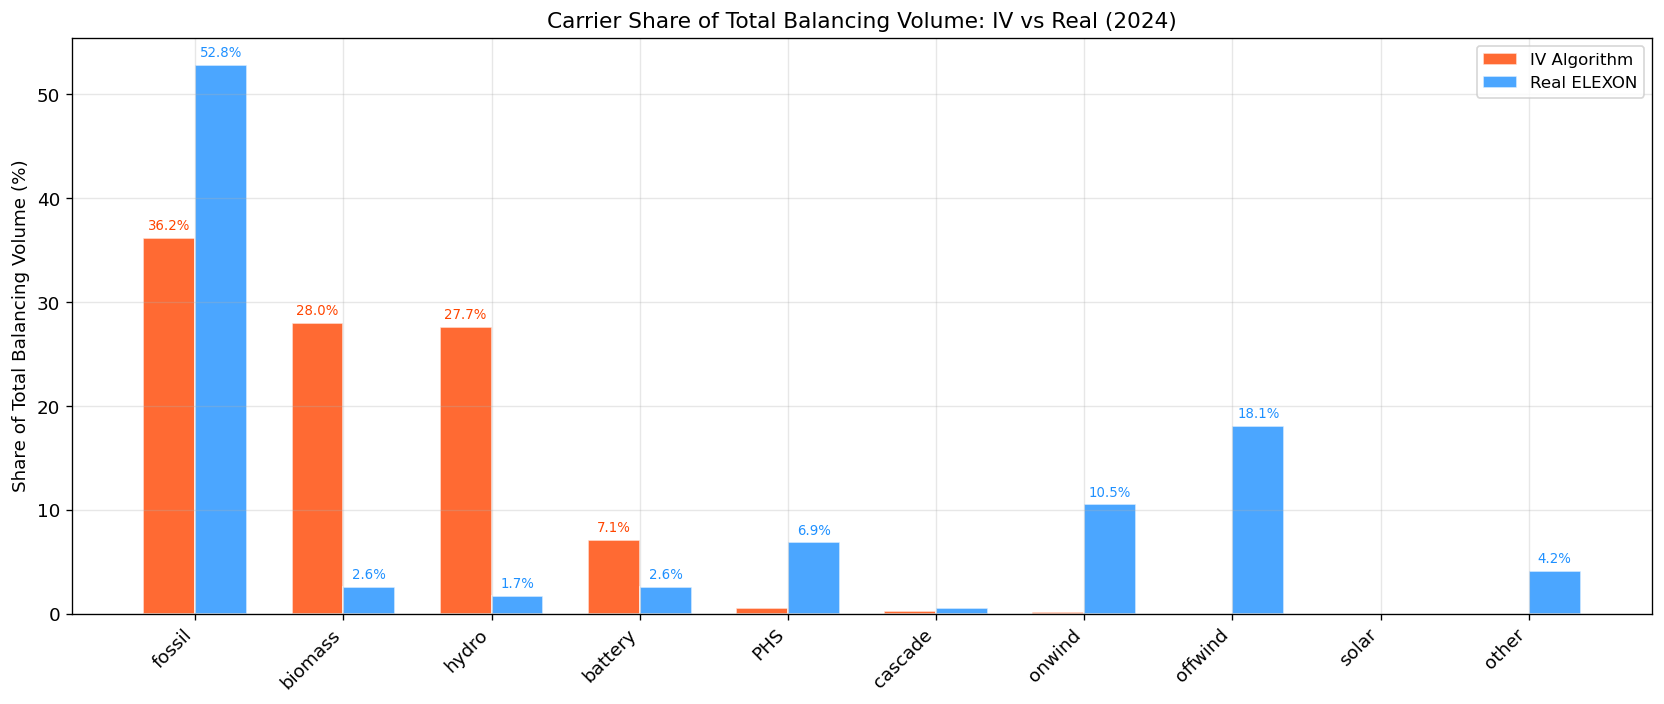

In [10]:
# Compute percentage shares
iv_share = (iv_by_carrier['total'] / iv_by_carrier['total'].sum() * 100).sort_values(ascending=False)
real_share = (real_by_carrier['total'] / real_by_carrier['total'].sum() * 100).sort_values(ascending=False)

# Align on same carrier set
all_carriers_share = list(dict.fromkeys(list(iv_share.index) + list(real_share.index)))
iv_share = iv_share.reindex(all_carriers_share, fill_value=0)
real_share = real_share.reindex(all_carriers_share, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_carriers_share))
width = 0.35

ax.bar(x - width/2, iv_share, width, label='IV Algorithm',
       color='orangered', alpha=0.8, edgecolor='white')
ax.bar(x + width/2, real_share, width, label='Real ELEXON',
       color='dodgerblue', alpha=0.8, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(all_carriers_share, rotation=45, ha='right')
ax.set_ylabel('Share of Total Balancing Volume (%)')
ax.set_title('Carrier Share of Total Balancing Volume: IV vs Real (2024)')
ax.legend()

# Add percentage labels
for i, c in enumerate(all_carriers_share):
    if iv_share.iloc[i] > 1:
        ax.text(i - width/2, iv_share.iloc[i] + 0.5, f'{iv_share.iloc[i]:.1f}%',
                ha='center', va='bottom', fontsize=8, color='orangered')
    if real_share.iloc[i] > 1:
        ax.text(i + width/2, real_share.iloc[i] + 0.5, f'{real_share.iloc[i]:.1f}%',
                ha='center', va='bottom', fontsize=8, color='dodgerblue')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_carrier_share_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Plot 3b: Acceptance Rate by Zone × Carrier (IV Model)

**What fraction of submitted volume is actually accepted** by the IV clearing algorithm, broken down by carrier type and zone? This reveals which technologies are supply-constrained vs demand-limited — e.g., a high acceptance rate for wind in northern zones means most submitted wind curtailment is needed to manage congestion.

We compare submitted bids/offers against cleared actions per zone-carrier combination.

Loading submitted bids/offers: 100%|██████████| 366/366 [00:50<00:00,  7.20it/s]


Loaded submitted data for 366 days


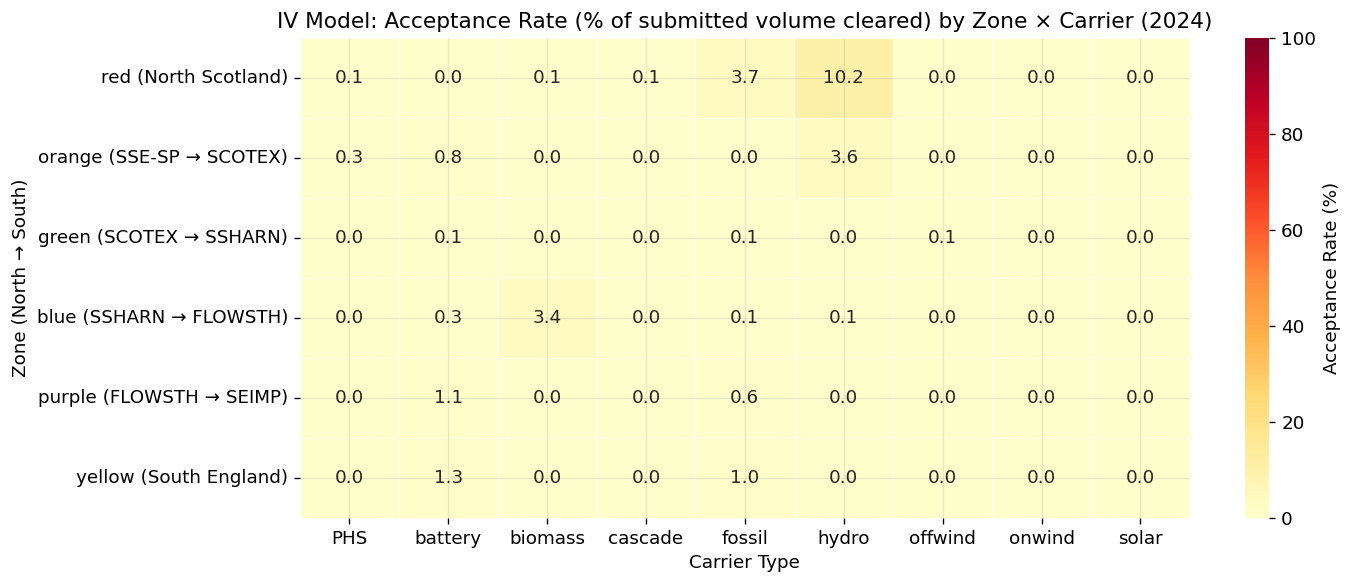


Acceptance rate summary:
carrier_type  PHS  battery  biomass  cascade  fossil  hydro  offwind  onwind  solar
zone                                                                               
red           0.1      0.0      0.1      0.1     3.7   10.2      0.0     0.0    0.0
orange        0.3      0.8      0.0      0.0     0.0    3.6      0.0     0.0    0.0
green         0.0      0.1      0.0      0.0     0.1    0.0      0.1     0.0    0.0
blue          0.0      0.3      3.4      0.0     0.1    0.1      0.0     0.0    0.0
purple        0.0      1.1      0.0      0.0     0.6    0.0      0.0     0.0    0.0
yellow        0.0      1.3      0.0      0.0     1.0    0.0      0.0     0.0    0.0


In [11]:
# Load submitted bids and offers across all days
submitted_list = []
missing_sub = 0

for day_str in tqdm(all_dates, desc="Loading submitted bids/offers"):
    for file_type, price_col in [('submitted_bids', 'Bid'), ('submitted_offers', 'Offer')]:
        fpath = DATA_DIR / day_str / f'{file_type}.csv'
        if not fpath.exists():
            if file_type == 'submitted_offers':
                missing_sub += 1
            continue
        
        df = pd.read_csv(fpath)
        # Volume is abs(LevelFrom) in MW per SP
        df['vol_mwh'] = df['LevelFrom'].abs() * 0.5
        
        # Map to carrier and zone
        df['carrier_type'] = df['NationalGridBmUnit'].map(
            bmu_class['carrier'].to_dict()
        ).fillna('other')
        df['zone'] = df['NationalGridBmUnit'].map(
            bmu_class['zone'].to_dict()
        ).fillna('unknown')
        
        action = 'bid' if file_type == 'submitted_bids' else 'offer'
        
        agg = df.groupby(['carrier_type', 'zone']).agg(
            submitted_vol=('vol_mwh', 'sum'),
            n_submissions=('vol_mwh', 'count'),
        ).reset_index()
        agg['action_type'] = action
        agg['date'] = day_str
        submitted_list.append(agg)

submitted_all = pd.concat(submitted_list, ignore_index=True)
submitted_all['date'] = pd.to_datetime(submitted_all['date'])

print(f"Loaded submitted data for {len(all_dates) - missing_sub} days")

# Aggregate submitted volume by carrier × zone
sub_agg = submitted_all.groupby(['carrier_type', 'zone'])['submitted_vol'].sum().reset_index()

# Aggregate accepted IV volume by carrier × zone
iv_agg = iv_actions.groupby(['carrier_type', 'zone'])['volume_mwh_actual'].sum().reset_index()
iv_agg.columns = ['carrier_type', 'zone', 'accepted_vol']

# Merge and compute acceptance rate
accept_df = sub_agg.merge(iv_agg, on=['carrier_type', 'zone'], how='left')
accept_df['accepted_vol'] = accept_df['accepted_vol'].fillna(0)
accept_df['acceptance_rate'] = (accept_df['accepted_vol'] / accept_df['submitted_vol'] * 100).clip(0, 100)

# Pivot for heatmap: zones as rows, carriers as columns
pivot = accept_df.pivot_table(
    index='zone', columns='carrier_type', values='acceptance_rate', fill_value=0
)

# Reorder zones north→south; keep only carriers with >0 submissions
zone_order_present = [z for z in ZONE_ORDER if z in pivot.index]
pivot = pivot.reindex(zone_order_present)
pivot = pivot.loc[:, pivot.sum() > 0]  # drop empty carriers

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Acceptance Rate (%)'}, ax=ax, vmin=0, vmax=100)
ax.set_yticklabels([f"{z} ({ZONE_NAMES.get(z, z)})" for z in zone_order_present], rotation=0)
ax.set_xlabel('Carrier Type')
ax.set_ylabel('Zone (North → South)')
ax.set_title('IV Model: Acceptance Rate (% of submitted volume cleared) by Zone × Carrier (2024)')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_acceptance_rate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAcceptance rate summary:")
print(pivot.round(1).to_string())

---
## Plot 3c: Top 20 Individual BMUs by Total Accepted Volume & Cost (IV Model)

Which individual generators/batteries carry the heaviest balancing load in the IV model? These are the "indispensable" units — if a single plant dominates, the results are sensitive to its availability and pricing.

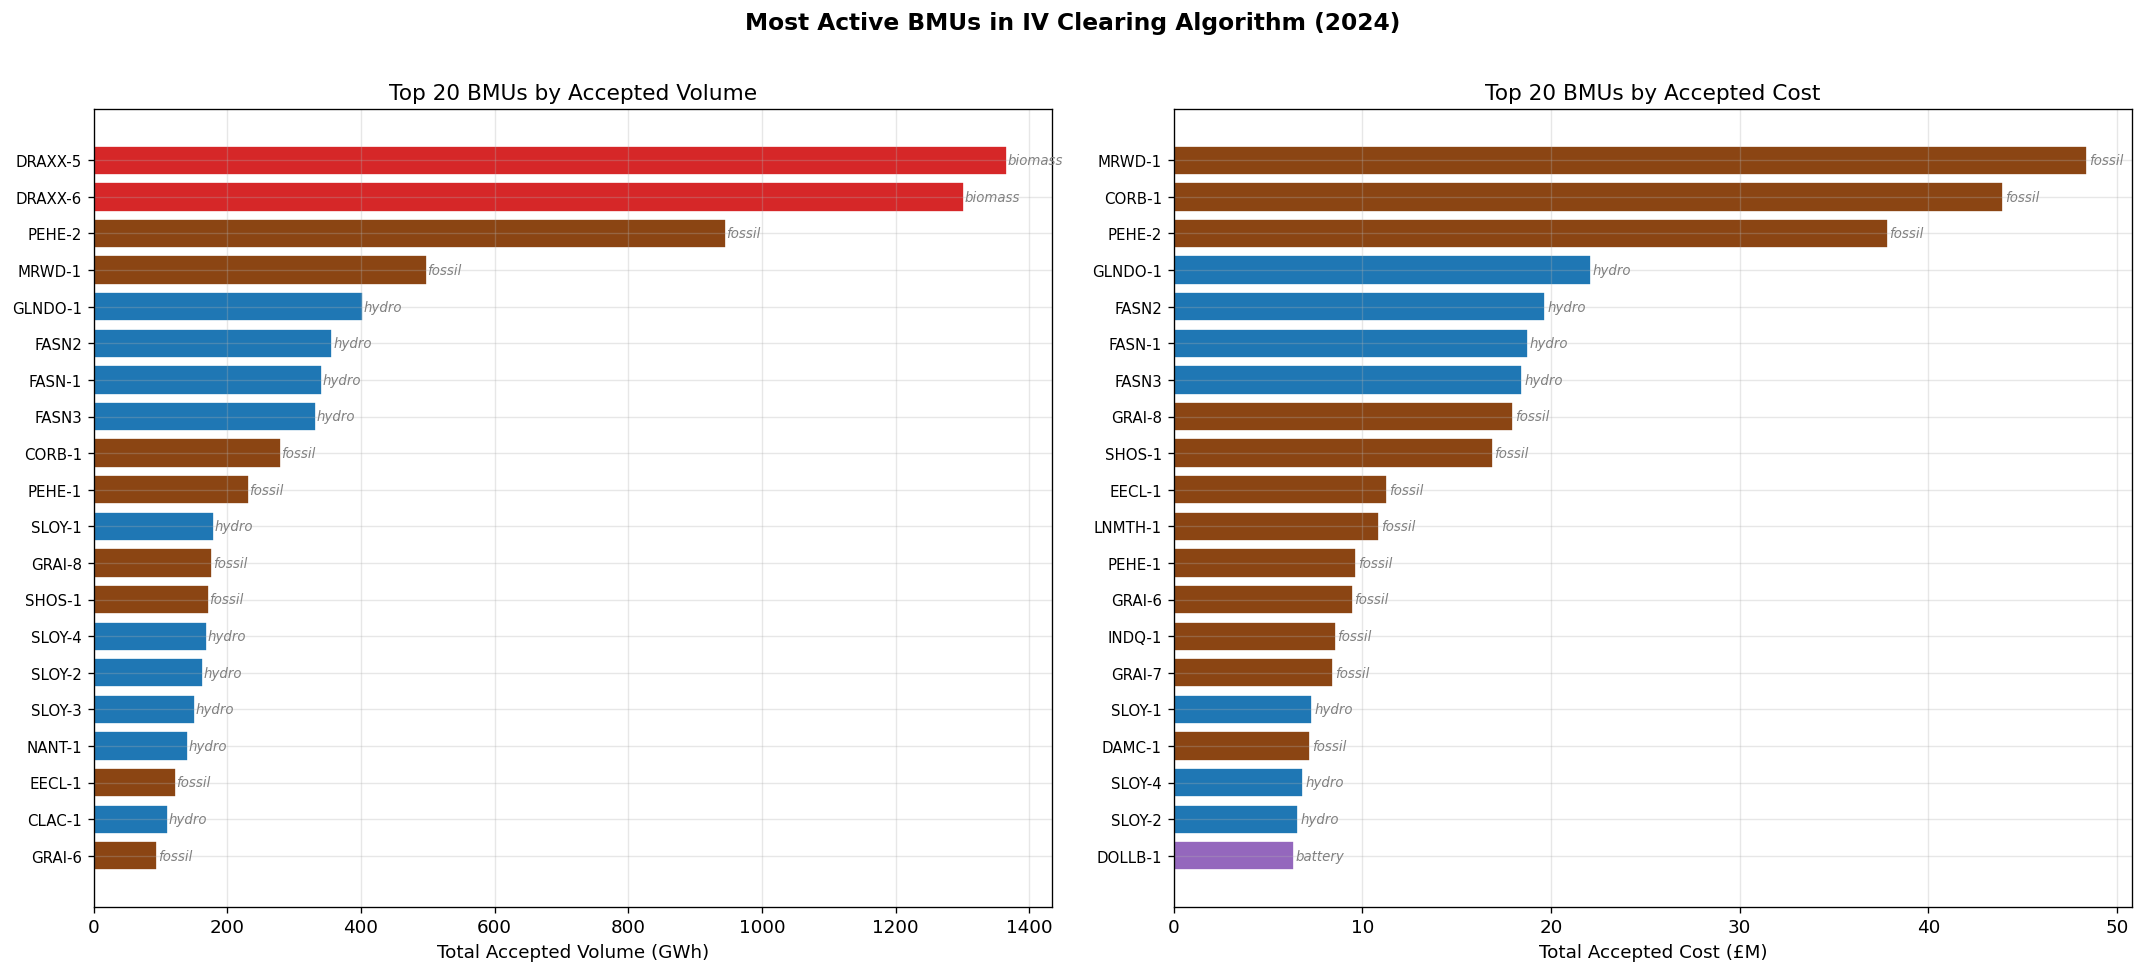


Top 20 BMUs by volume:
unit_id carrier_type total_vol_mwh total_cost_gbp  n_days cost_per_mwh
DRAXX-5      biomass    1366.3 GWh         £0.00M     350     £0.0/MWh
DRAXX-6      biomass    1302.2 GWh         £0.00M     339     £0.0/MWh
 PEHE-2       fossil     945.9 GWh        £37.84M     171    £40.0/MWh
 MRWD-1       fossil     498.6 GWh        £48.40M     251    £97.1/MWh
GLNDO-1        hydro     402.3 GWh        £22.11M     216    £55.0/MWh
  FASN2        hydro     357.2 GWh        £19.69M     226    £55.1/MWh
 FASN-1        hydro     341.2 GWh        £18.76M     210    £55.0/MWh
  FASN3        hydro     332.2 GWh        £18.47M     200    £55.6/MWh
 CORB-1       fossil     279.7 GWh        £43.98M     105   £157.2/MWh
 PEHE-1       fossil     231.7 GWh         £9.67M     109    £41.7/MWh
 SLOY-1        hydro     180.6 GWh         £7.35M     185    £40.7/MWh
 GRAI-8       fossil     177.3 GWh        £18.01M     195   £101.5/MWh
 SHOS-1       fossil     172.4 GWh        £16.91M    

In [12]:
# Aggregate by unit
top_units = iv_actions.groupby(['unit_id', 'carrier_type']).agg(
    total_vol_mwh=('volume_mwh_actual', 'sum'),
    total_cost_gbp=('cost_gbp', 'sum'),
    n_actions=('volume_mwh_actual', 'count'),
    n_days=('date', 'nunique'),
    mean_price=('price_per_mwh', 'mean'),
).reset_index()

top_units['cost_per_mwh'] = top_units['total_cost_gbp'] / top_units['total_vol_mwh'].replace(0, np.nan)

# Top 20 by volume
top20_vol = top_units.nlargest(20, 'total_vol_mwh')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Panel 1: Top 20 by volume
ax = axes[0]
colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in top20_vol['carrier_type']]
y_pos = np.arange(len(top20_vol))
ax.barh(y_pos, top20_vol['total_vol_mwh'] / 1e3, color=colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(top20_vol['unit_id'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Total Accepted Volume (GWh)')
ax.set_title('Top 20 BMUs by Accepted Volume')

# Add carrier labels
for i, (_, row) in enumerate(top20_vol.iterrows()):
    ax.text(row['total_vol_mwh']/1e3 + 1, i, row['carrier_type'],
            va='center', fontsize=8, style='italic', color='grey')

# Panel 2: Top 20 by cost
top20_cost = top_units.nlargest(20, 'total_cost_gbp')
ax = axes[1]
colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in top20_cost['carrier_type']]
y_pos = np.arange(len(top20_cost))
ax.barh(y_pos, top20_cost['total_cost_gbp'] / 1e6, color=colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(top20_cost['unit_id'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Total Accepted Cost (£M)')
ax.set_title('Top 20 BMUs by Accepted Cost')

for i, (_, row) in enumerate(top20_cost.iterrows()):
    ax.text(row['total_cost_gbp']/1e6 + 0.1, i, row['carrier_type'],
            va='center', fontsize=8, style='italic', color='grey')

fig.suptitle('Most Active BMUs in IV Clearing Algorithm (2024)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_top20_bmus.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nTop 20 BMUs by volume:")
display_cols = ['unit_id', 'carrier_type', 'total_vol_mwh', 'total_cost_gbp', 'n_days', 'cost_per_mwh']
top20_display = top20_vol[display_cols].copy()
top20_display['total_vol_mwh'] = top20_display['total_vol_mwh'].map(lambda x: f"{x/1e3:.1f} GWh")
top20_display['total_cost_gbp'] = top20_display['total_cost_gbp'].map(lambda x: f"£{x/1e6:.2f}M")
top20_display['cost_per_mwh'] = top20_display['cost_per_mwh'].map(lambda x: f"£{x:.1f}/MWh")
print(top20_display.to_string(index=False))

---
## Plot 3d: Technology Composition by Zone and Direction (IV Model)

Stacked bars showing which carriers provide flex-up vs flex-down in each zone. This is the core spatial story:
- **Northern zones**: expect wind curtailment (turndown) + some hydro
- **Central/Southern zones**: expect gas CCGT offers (turn-up) + battery arbitrage

Uses `IV_dispatch_changes_by_zone_and_type_flex.csv` summed across 366 days.

Loading dispatch changes: 100%|██████████| 366/366 [00:05<00:00, 72.94it/s]


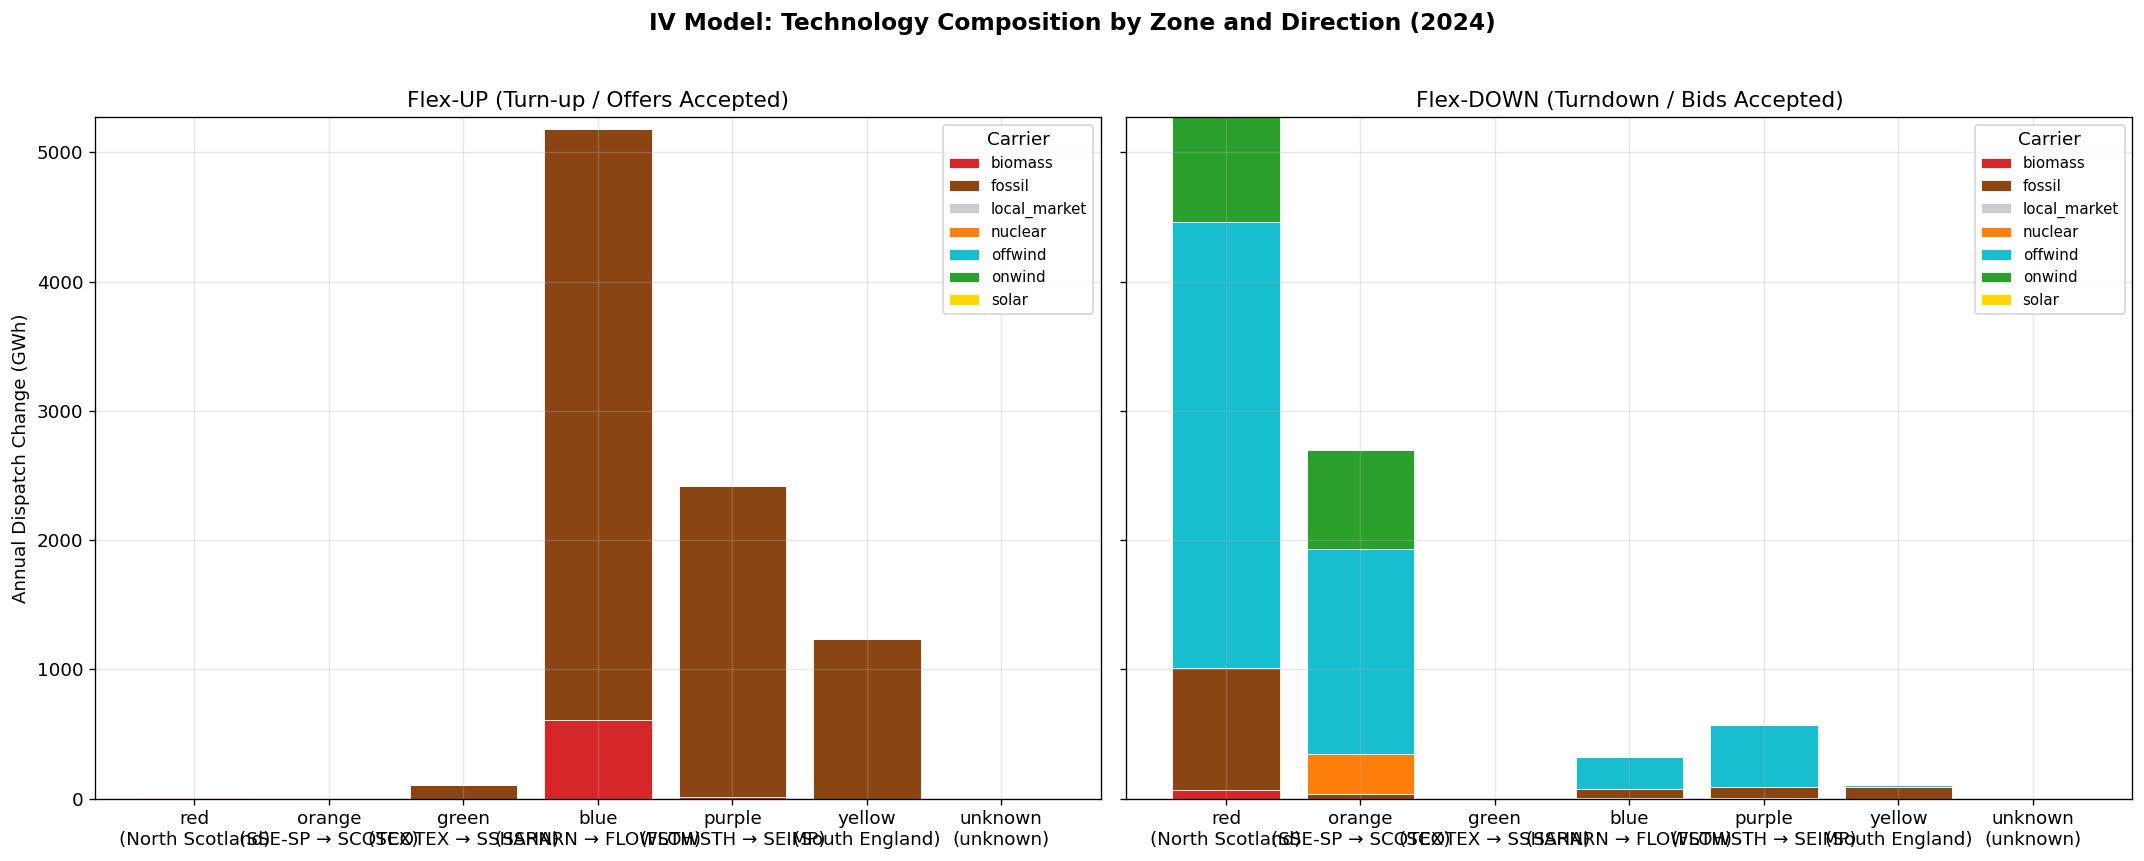


Flex-Up by zone (GWh):
type     biomass  fossil  local_market  nuclear  offwind  onwind  solar
zone                                                                   
red          0.8    11.6           0.0      0.0      0.0     0.0    0.0
orange       0.0     4.2           0.0      0.0      0.0     0.0    0.0
green        0.0   107.0           0.0      0.0      0.0     0.0    0.0
blue       610.5  4570.0           0.0      0.0      6.0     0.0    0.0
purple      12.6  2403.2           0.0      0.0      0.2     0.0    0.0
yellow       0.0  1235.6           0.0      0.0      0.0     0.0    0.0
unknown      0.0     0.0           0.0      0.0      0.0     0.0    0.0

Flex-Down by zone (GWh):
type     biomass  fossil  local_market  nuclear  offwind  onwind  solar
zone                                                                   
red         62.4   950.0           0.0      0.0   3445.0   813.3    0.0
orange       0.0    37.2           0.0    309.0   1584.4   763.9    0.0
green        0

In [13]:
# Load dispatch changes by zone and type for all days
dispatch_list = []

for day_str in tqdm(all_dates, desc="Loading dispatch changes"):
    fpath = RESULTS_DIR / day_str / 'IV_dispatch_changes_by_zone_and_type_flex.csv'
    if not fpath.exists():
        continue
    try:
        df = pd.read_csv(fpath)
        if df.empty:
            continue
    except Exception:
        continue
    df['date'] = day_str
    dispatch_list.append(df)

dispatch_all = pd.concat(dispatch_list, ignore_index=True)

# Aggregate: sum dispatch_change_mwh by zone × type × direction across the year
disp_agg = dispatch_all.groupby(['zone', 'type', 'direction'])['dispatch_change_mwh'].sum().reset_index()

# Separate up and down
disp_up = disp_agg[disp_agg['direction'] == 'up'].copy()
disp_down = disp_agg[disp_agg['direction'] == 'down'].copy()

# Pivot for stacked bars
pivot_up = disp_up.pivot_table(index='zone', columns='type', values='dispatch_change_mwh', fill_value=0)
pivot_down = disp_down.pivot_table(index='zone', columns='type', values='dispatch_change_mwh', fill_value=0)

# Make down absolute for plotting
pivot_down = pivot_down.abs()

# Reorder zones
zones_present = [z for z in ZONE_ORDER + ['unknown'] if z in pivot_up.index or z in pivot_down.index]
pivot_up = pivot_up.reindex(zones_present, fill_value=0)
pivot_down = pivot_down.reindex(zones_present, fill_value=0)

# Get all carriers across both
all_types = sorted(set(list(pivot_up.columns) + list(pivot_down.columns)))
pivot_up = pivot_up.reindex(columns=all_types, fill_value=0)
pivot_down = pivot_down.reindex(columns=all_types, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Zone labels with names
zone_labels = [f"{z}\n({ZONE_NAMES.get(z, z)})" for z in zones_present]

# Plot up
ax = axes[0]
bottom = np.zeros(len(zones_present))
for carrier in all_types:
    vals = pivot_up[carrier].values / 1e3  # GWh
    ax.bar(zone_labels, vals, bottom=bottom, label=carrier,
           color=CARRIER_COLORS.get(carrier, '#CCCCCC'), edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_ylabel('Annual Dispatch Change (GWh)')
ax.set_title('Flex-UP (Turn-up / Offers Accepted)')
ax.legend(title='Carrier', loc='upper right', fontsize=9)

# Plot down
ax = axes[1]
bottom = np.zeros(len(zones_present))
for carrier in all_types:
    vals = pivot_down[carrier].values / 1e3  # GWh
    ax.bar(zone_labels, vals, bottom=bottom, label=carrier,
           color=CARRIER_COLORS.get(carrier, '#CCCCCC'), edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_title('Flex-DOWN (Turndown / Bids Accepted)')
ax.legend(title='Carrier', loc='upper right', fontsize=9)

fig.suptitle('IV Model: Technology Composition by Zone and Direction (2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_zone_tech_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFlex-Up by zone (GWh):")
print((pivot_up / 1e3).round(1).to_string())
print("\nFlex-Down by zone (GWh):")
print((pivot_down / 1e3).round(1).to_string())

---
## Plot 3e: Monthly Technology Mix Evolution

How does the carrier mix change across seasons? Wind curtailment should peak in winter (high wind), battery usage may peak in summer (solar patterns), and gas usage may track demand peaks.

Stacked area chart showing monthly contribution of each carrier to total IV balancing volume.

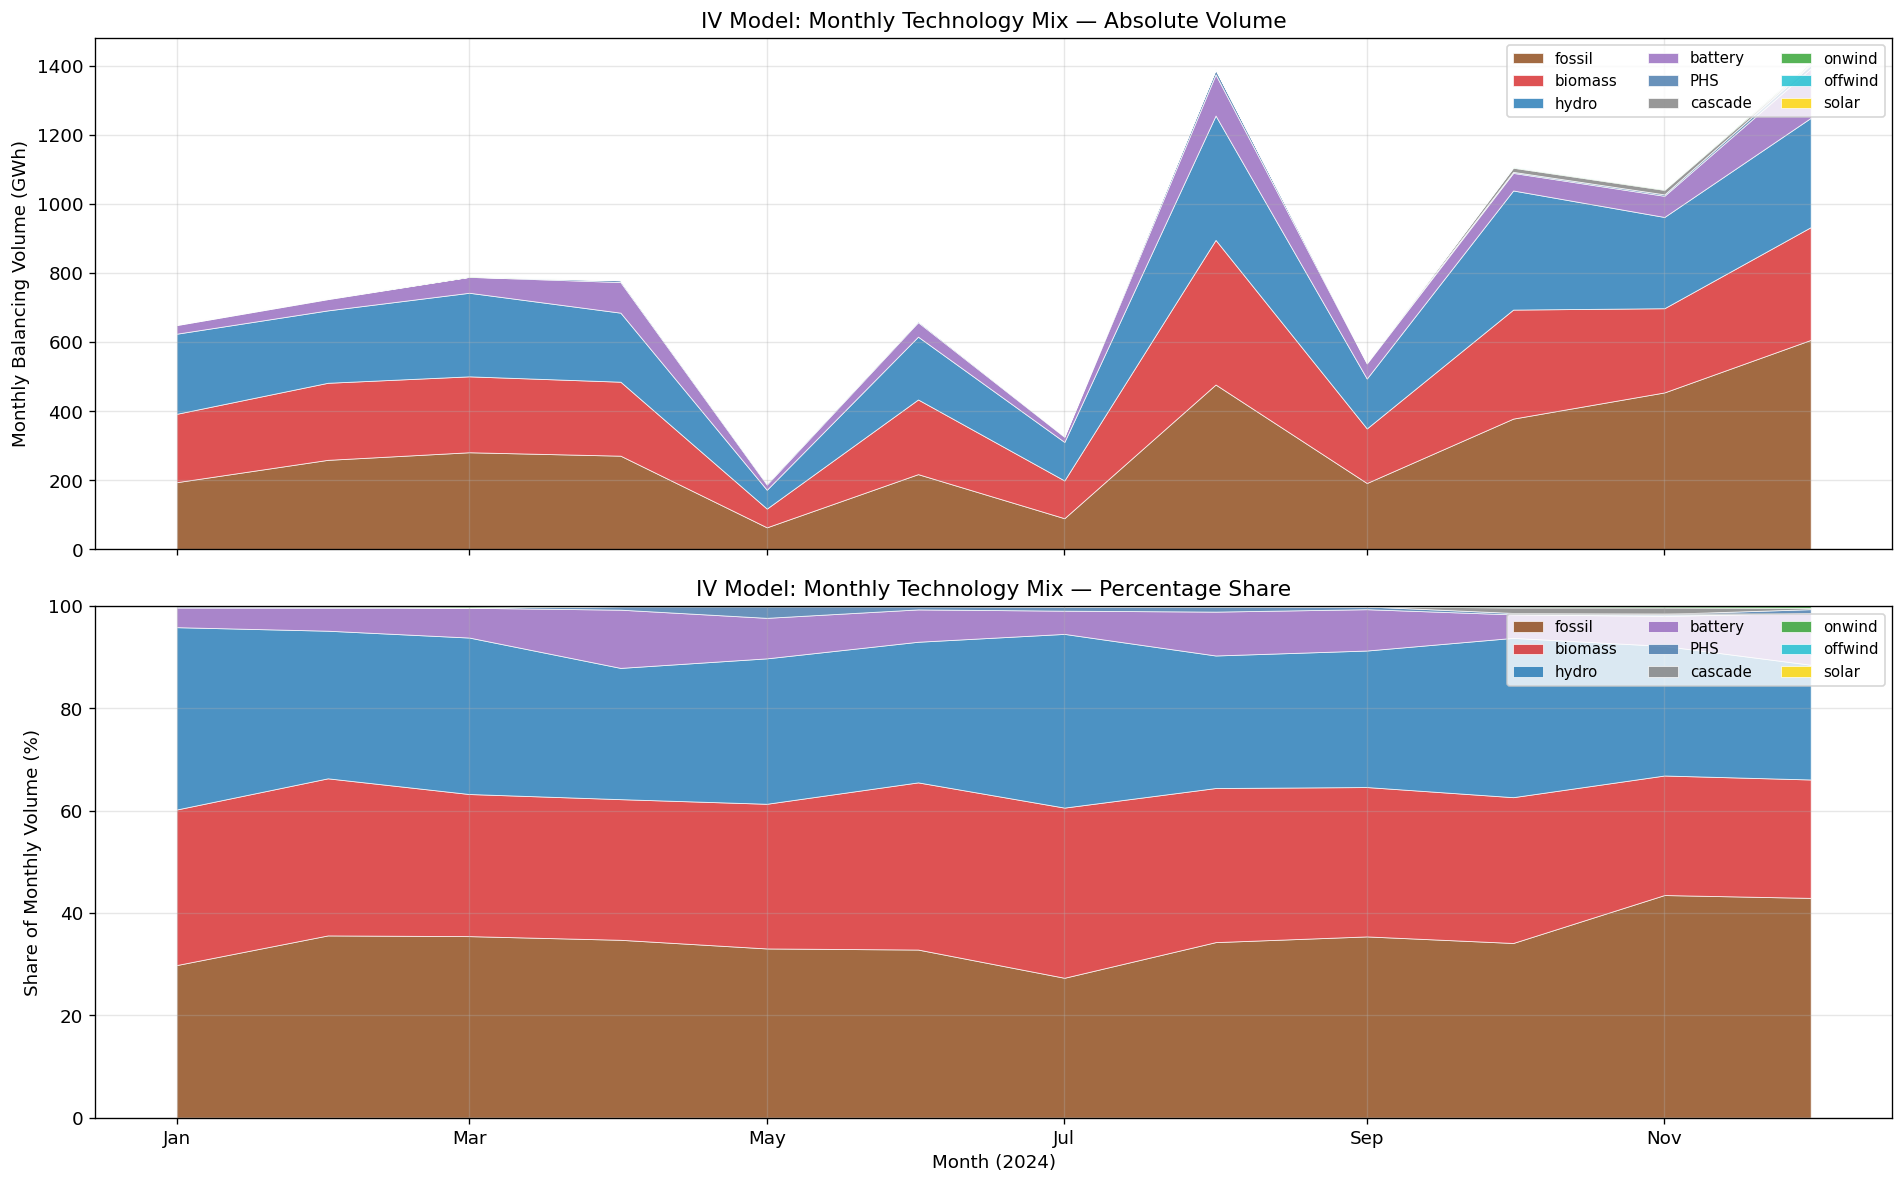

Monthly volume by carrier (GWh):
carrier_type  fossil  biomass  hydro  battery   PHS  cascade  onwind  offwind  solar
month                                                                               
2024-01        194.2    198.0  232.1     25.0   1.5      0.0     0.4      0.0    0.0
2024-02        258.9    223.2  209.7     32.6   1.6      0.0     0.9      0.0    0.0
2024-03        280.9    219.9  242.1     46.1   0.2      0.1     1.9      0.4    0.0
2024-04        271.0    214.3  200.0     88.7   5.2      0.1     0.3      0.0    0.0
2024-05         63.5     54.3   54.5     15.2   4.3      0.0     0.1      0.0    0.0
2024-06        217.5    216.3  182.0     41.9   4.0      0.0     0.3      0.0    0.0
2024-07         89.9    109.3  111.6     14.9   2.7      0.0     0.1      0.2    0.0
2024-08        477.2    418.9  360.3    119.2  14.0      0.0     1.2      0.0    0.0
2024-09        191.8    158.1  144.5     43.7   2.9      0.0     0.1      0.4    0.0
2024-10        378.4    315.8  3

In [14]:
# Monthly carrier breakdown for IV model
iv_monthly = iv_actions.groupby(['month', 'carrier_type'])['volume_mwh_actual'].sum().unstack(fill_value=0)
iv_monthly = iv_monthly / 1e3  # GWh

# Sort carriers by total contribution (largest on bottom of stack)
carrier_order = iv_monthly.sum().sort_values(ascending=False).index.tolist()
iv_monthly = iv_monthly[carrier_order]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel 1: Stacked area (absolute GWh)
ax = axes[0]
month_dates = [p.to_timestamp() for p in iv_monthly.index]
colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in carrier_order]

ax.stackplot(month_dates, [iv_monthly[c].values for c in carrier_order],
             labels=carrier_order, colors=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Monthly Balancing Volume (GWh)')
ax.set_title('IV Model: Monthly Technology Mix — Absolute Volume')
ax.legend(loc='upper right', ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Panel 2: Normalised (% share)
ax = axes[1]
iv_monthly_pct = iv_monthly.div(iv_monthly.sum(axis=1), axis=0) * 100

ax.stackplot(month_dates, [iv_monthly_pct[c].values for c in carrier_order],
             labels=carrier_order, colors=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Share of Monthly Volume (%)')
ax.set_xlabel('Month (2024)')
ax.set_title('IV Model: Monthly Technology Mix — Percentage Share')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_tech_mix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Monthly volume by carrier (GWh):")
print(iv_monthly.round(1).to_string())

---
## Plot 3f: Price Distribution by Carrier Type (IV Accepted Actions)

Box plots showing the distribution of accepted prices for each carrier type, split by direction. This reveals **why** the merit-order algorithm selects certain technologies:
- Cheap carriers with low offer prices get selected first for turn-up
- Carriers with high bid prices get selected first for turndown
- The spread shows how consistently competitive each technology is

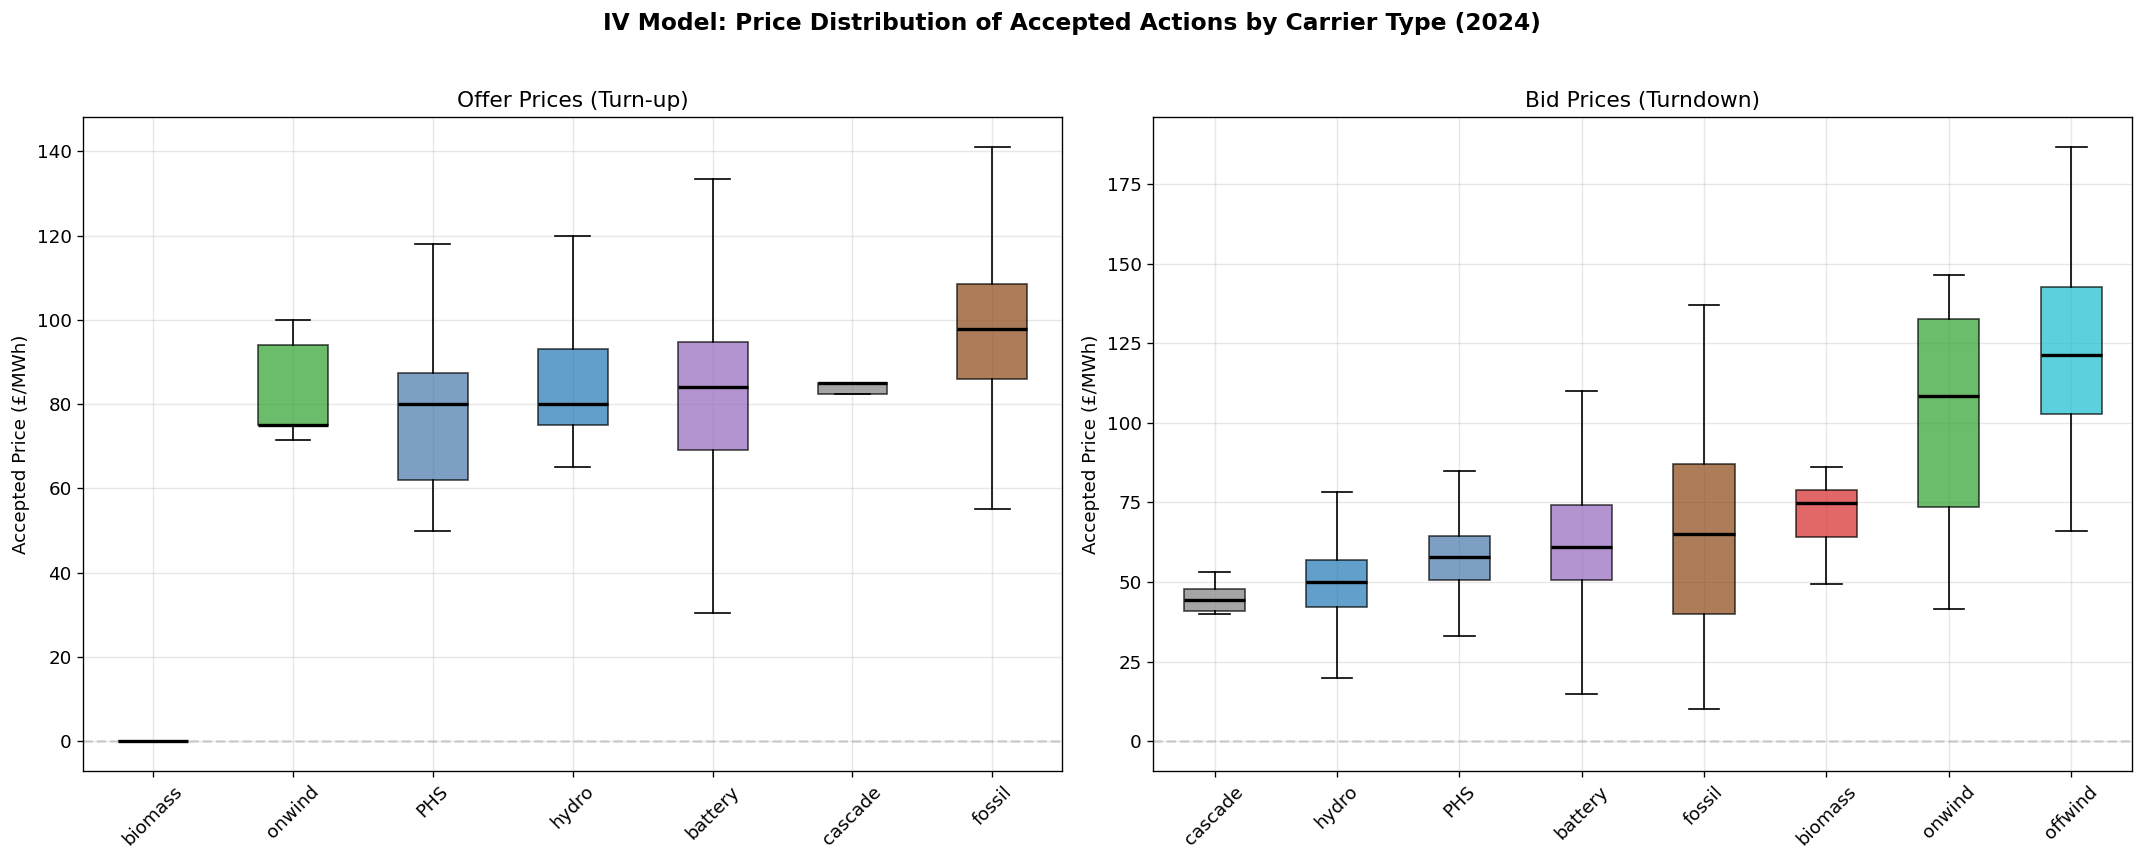


Median accepted price by carrier and direction:
                          median    mean  count
carrier_type action_type                       
PHS          bid           57.80   56.82    771
             offer         80.00   77.06     95
battery      bid           61.00   61.00  11544
             offer         84.00   81.82  36803
biomass      bid           74.70   72.68    120
             offer          0.00    1.44  14431
cascade      bid           44.28   40.92    220
             offer         85.00   82.55    108
fossil       bid           65.00   82.02  25594
             offer         98.00  119.45  15516
hydro        bid           50.00   48.22  38296
             offer         80.00   87.96    293
offwind      bid          -92.78  -82.86    147
onwind       bid          124.57  125.76     84
             offer         75.00   83.68    607


In [15]:
# Filter to carriers with enough data points
carrier_counts = iv_actions['carrier_type'].value_counts()
major_carriers = carrier_counts[carrier_counts > 100].index.tolist()

iv_major = iv_actions[iv_actions['carrier_type'].isin(major_carriers)].copy()

# Clip extreme prices for readability
p_low, p_high = iv_major['price_per_mwh'].quantile(0.01), iv_major['price_per_mwh'].quantile(0.99)
iv_major_clipped = iv_major[(iv_major['price_per_mwh'] >= p_low) & (iv_major['price_per_mwh'] <= p_high)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, direction, title in [
    (axes[0], 'offer', 'Offer Prices (Turn-up)'),
    (axes[1], 'bid', 'Bid Prices (Turndown)'),
]:
    data = iv_major_clipped[iv_major_clipped['action_type'] == direction]
    if data.empty:
        ax.set_title(f'{title} — No data')
        continue
    
    # Order carriers by median price
    order = data.groupby('carrier_type')['price_per_mwh'].median().sort_values().index.tolist()
    
    box_colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in order]
    
    bp = ax.boxplot(
        [data[data['carrier_type'] == c]['price_per_mwh'].values for c in order],
        labels=order, patch_artist=True, showfliers=False,
        medianprops=dict(color='black', linewidth=2),
    )
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Accepted Price (£/MWh)')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(0, color='grey', ls='--', alpha=0.3)

fig.suptitle('IV Model: Price Distribution of Accepted Actions by Carrier Type (2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_price_by_carrier.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("\nMedian accepted price by carrier and direction:")
price_summary = iv_major.groupby(['carrier_type', 'action_type'])['price_per_mwh'].agg(['median', 'mean', 'count'])
print(price_summary.round(2).to_string())

---
## Plot 3g: IV vs Real — Technology Share Comparison by Zone

Direct comparison: for each zone, what share of balancing volume comes from each carrier? Side-by-side IV vs Real. This is perhaps the most informative single chart — it shows both the geographic and technology dimensions simultaneously, and reveals where the model's selection logic diverges most from the real SO.

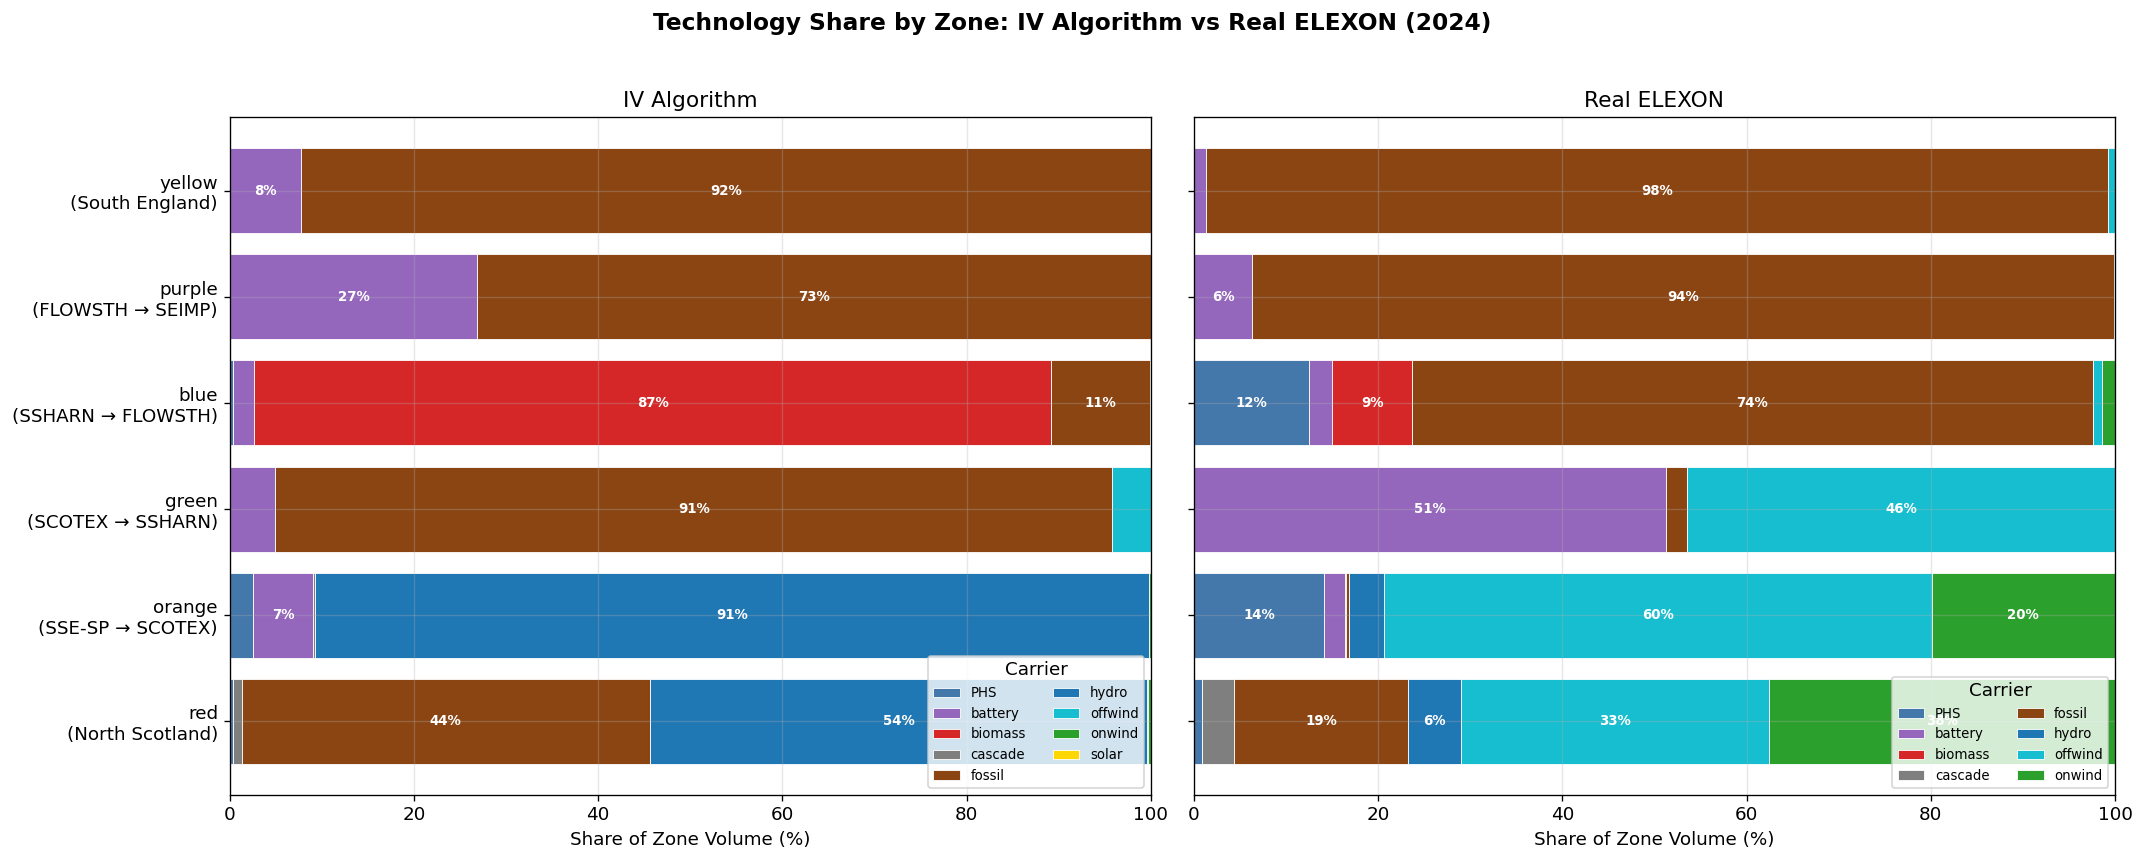

In [16]:
# IV: volume by zone × carrier
iv_zone_carrier = iv_actions.groupby(['zone', 'carrier_type'])['volume_mwh_actual'].sum().unstack(fill_value=0)

# Real: volume by zone × carrier
real_zone_carrier = real_actions.groupby(['zone', 'carrier_type'])['volume_mwh'].sum().unstack(fill_value=0)

# Normalise to % within each zone
iv_zone_pct = iv_zone_carrier.div(iv_zone_carrier.sum(axis=1), axis=0) * 100
real_zone_pct = real_zone_carrier.div(real_zone_carrier.sum(axis=1), axis=0) * 100

# Align zones and carriers
zones_common = [z for z in ZONE_ORDER if z in iv_zone_pct.index or z in real_zone_pct.index]
all_carriers_zc = sorted(set(list(iv_zone_pct.columns) + list(real_zone_pct.columns)))

iv_zone_pct = iv_zone_pct.reindex(index=zones_common, columns=all_carriers_zc, fill_value=0)
real_zone_pct = real_zone_pct.reindex(index=zones_common, columns=all_carriers_zc, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, data, title in [
    (axes[0], iv_zone_pct, 'IV Algorithm'),
    (axes[1], real_zone_pct, 'Real ELEXON'),
]:
    zone_labels = [f"{z}\n({ZONE_NAMES.get(z, z)})" for z in zones_common]
    bottom = np.zeros(len(zones_common))
    
    for carrier in all_carriers_zc:
        vals = data[carrier].values
        if vals.sum() == 0:
            continue
        ax.barh(zone_labels, vals, left=bottom, label=carrier,
                color=CARRIER_COLORS.get(carrier, '#CCCCCC'), edgecolor='white', linewidth=0.5)
        
        # Label segments > 5%
        for i, v in enumerate(vals):
            if v > 5:
                ax.text(bottom[i] + v/2, i, f'{v:.0f}%',
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        bottom += vals
    
    ax.set_xlabel('Share of Zone Volume (%)')
    ax.set_title(title)
    ax.set_xlim(0, 100)
    ax.legend(title='Carrier', loc='lower right', fontsize=8, ncol=2)

fig.suptitle('Technology Share by Zone: IV Algorithm vs Real ELEXON (2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_zone_tech_share_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary Statistics

In [17]:
print("=" * 80)
print("TECHNOLOGY MIX SUMMARY — IV ALGORITHM vs REAL ELEXON (2024)")
print("=" * 80)

print("\n--- IV Model —--")
iv_summary = iv_actions.groupby('carrier_type').agg(
    vol_gwh=('volume_mwh_actual', lambda x: x.sum()/1e3),
    cost_mGBP=('cost_gbp', lambda x: x.sum()/1e6),
    n_units=('unit_id', 'nunique'),
    n_days=('date', 'nunique'),
    median_price=('price_per_mwh', 'median'),
).sort_values('vol_gwh', ascending=False)
iv_summary['share_pct'] = iv_summary['vol_gwh'] / iv_summary['vol_gwh'].sum() * 100
iv_summary['cost_per_mwh'] = iv_summary['cost_mGBP'] * 1e3 / iv_summary['vol_gwh']  # £/MWh
print(iv_summary.round(2).to_string())

print("\n--- Real ELEXON ---")
real_summary = real_actions.groupby('carrier_type').agg(
    vol_gwh=('volume_mwh', lambda x: x.sum()/1e3),
    cost_mGBP=('cost_gbp', lambda x: x.sum()/1e6),
    n_bmus=('bmu', 'nunique'),
    n_days=('date', 'nunique'),
).sort_values('vol_gwh', ascending=False)
real_summary['share_pct'] = real_summary['vol_gwh'] / real_summary['vol_gwh'].sum() * 100
real_summary['cost_per_mwh'] = real_summary['cost_mGBP'] * 1e3 / real_summary['vol_gwh']  # £/MWh
print(real_summary.round(2).to_string())

print("\n--- Key Differences ---")
# Merge on carrier
comp = iv_summary[['share_pct']].rename(columns={'share_pct': 'IV share %'})
comp = comp.join(real_summary[['share_pct']].rename(columns={'share_pct': 'Real share %'}), how='outer').fillna(0)
comp['Difference (pp)'] = comp['IV share %'] - comp['Real share %']
comp = comp.sort_values('Difference (pp)', key=abs, ascending=False)
print(comp.round(1).to_string())

print("\n--- Interpretation ---")
most_overrepped = comp['Difference (pp)'].idxmax()
most_underrepped = comp['Difference (pp)'].idxmin()
print(f"Most over-represented in IV model:  {most_overrepped} ({comp.loc[most_overrepped, 'Difference (pp)']:+.1f} pp)")
print(f"Most under-represented in IV model: {most_underrepped} ({comp.loc[most_underrepped, 'Difference (pp)']:+.1f} pp)")

TECHNOLOGY MIX SUMMARY — IV ALGORITHM vs REAL ELEXON (2024)

--- IV Model —--
              vol_gwh  cost_mGBP  n_units  n_days  median_price  share_pct  cost_per_mwh
carrier_type                                                                            
fossil        3483.84     298.36       79     348         83.50      36.19         85.64
biomass       2698.50       2.51        7     353          0.00      28.03          0.93
hydro         2662.72     126.72       16     334         50.00      27.66         47.59
battery        682.36      53.32       65     321         79.00       7.09         78.14
PHS             54.09       2.96       11      92         59.40       0.56         54.75
cascade         28.89       1.42        5      37         47.94       0.30         49.24
onwind          14.26       1.32       11      96         93.00       0.15         92.36
offwind          2.91      -0.18        4      25        -92.78       0.03        -60.33
solar            0.02       0.00